In [1]:
import os
import pandas as pd

print("Current working directory:")
print(os.getcwd())


Current working directory:
d:\sumanthnitte\dark-pattern-classifier


In [2]:
print("Files in the current folder:")

for file in os.listdir():
    print(file)

Files in the current folder:
.git
.vscode
AI-Powered _Dark Pattern_ Text Classifier.ipynb
app.py
dark_pattern_model.pkl
notebook_code.txt
patterns.csv
pattern_classifications.csv
pattern_classifications_improved.csv
tfidf_vectorizer.pkl


In [2]:
import pandas as pd
from pathlib import Path

# Improved dataset is in the same folder as this notebook
file_path = Path("pattern_classifications_improved.csv")

# Check whether the dataset exists
if not file_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {file_path.resolve()}"
    )

# Load improved dataset
df = pd.read_csv(file_path)

print("Improved dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClassification distribution:")
print(df["classification"].value_counts())

Improved dataset loaded successfully!
Dataset shape: (2000, 2)

Columns:
['Pattern String', 'classification']

First 5 rows:


,Pattern String,classification
0,Recipe app is available for pre-order.,0
1,Sponsored content about subscription box disgu...,1
2,We'll renew your webcam without a reminder ema...,1
3,Manage your cookie preferences for office chai...,0
4,Hurry! The dating app deal disappears in 5 min...,1



Missing values:
Pattern String    0
classification    0
dtype: int64

Classification distribution:
classification
0    1000
1    1000
Name: count, dtype: int64


In [3]:
# Prepare features and labels

X = df["Pattern String"].astype(str)
y = df["classification"].astype(int)

print("Total samples:", len(X))

print("\nClass distribution:")
print(y.value_counts())

print("\nClass percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Total samples: 2000

Class distribution:
classification
0    1000
1    1000
Name: count, dtype: int64

Class percentages:
classification
0    50.0
1    50.0
Name: proportion, dtype: float64


In [4]:
# STEP 2: Inspect the improved dataset

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClassification distribution:")
print(df["classification"].value_counts())

print("\nClassification percentages:")
print((df["classification"].value_counts(normalize=True) * 100).round(2))

print("\n--- DECEPTIVE EXAMPLES ---")
display(
    df[df["classification"] == 1][
        ["Pattern String", "classification"]
    ].head(20)
)

print("\n--- NON-DECEPTIVE EXAMPLES ---")
display(
    df[df["classification"] == 0][
        ["Pattern String", "classification"]
    ].head(20)
)

Dataset shape: (2000, 2)

Missing values:
Pattern String    0
classification    0
dtype: int64

Classification distribution:
classification
0    1000
1    1000
Name: count, dtype: int64

Classification percentages:
classification
0    50.0
1    50.0
Name: proportion, dtype: float64

--- DECEPTIVE EXAMPLES ---


,Pattern String,classification
1,Sponsored content about subscription box disgu...,1
2,We'll renew your webcam without a reminder ema...,1
4,Hurry! The dating app deal disappears in 5 min...,1
5,"Complete your pro subscription order now, leav...",1
6,This offer on bicycle helmet vanishes the mome...,1
8,Real professionals never use the free version ...,1
11,"No thanks, I don't care about my own savings o...",1
16,"Only losers stay on the basic plan, upgrade yo...",1
19,Voted best running shoes by everyone! (No actu...,1
20,"Was ₹9999, now ₹999 on standing desk! (Origina...",1



--- NON-DECEPTIVE EXAMPLES ---


,Pattern String,classification
0,Recipe app is available for pre-order.,0
3,Manage your cookie preferences for office chai...,0
7,You will be billed ₹299 monthly for stock trad...,0
9,Your free trial of recipe book ends on Septemb...,0
10,Food delivery app is available in three colours.,0
12,Payment successful for your streaming service ...,0
13,Stock trading app is available in three colours.,0
14,Insurance plan weighs approximately 500 grams.,0
15,"Your order total for coffee maker is ₹1,249 in...",0
17,Order confirmed: your denim jacket has been pl...,0


In [5]:
# STEP 3: Inspect sample examples from both classes

print("=" * 80)
print("DECEPTIVE EXAMPLES (classification = 1)")
print("=" * 80)

deceptive_examples = df[df["classification"] == 1]["Pattern String"].head(30)

for i, text in enumerate(deceptive_examples, 1):
    print(f"{i}. {text}")


print("\n" + "=" * 80)
print("NON-DECEPTIVE EXAMPLES (classification = 0)")
print("=" * 80)

non_deceptive_examples = df[df["classification"] == 0]["Pattern String"].head(30)

for i, text in enumerate(non_deceptive_examples, 1):
    print(f"{i}. {text}")

DECEPTIVE EXAMPLES (classification = 1)
1. Sponsored content about subscription box disguised as independent editorial advice.
2. We'll renew your webcam without a reminder email, as stated deep in section 14.3.
3. Hurry! The dating app deal disappears in 5 minutes!
4. Complete your pro subscription order now, leaving means losing your cart forever!
5. This offer on bicycle helmet vanishes the moment you leave this page!
6. Real professionals never use the free version of travel booking site, upgrade immediately!
7. No thanks, I don't care about my own savings on smartwatch.
8. Only losers stay on the basic plan, upgrade your antivirus subscription now!
9. Voted best running shoes by everyone! (No actual voting ever took place.)
10. Was ₹9999, now ₹999 on standing desk! (Original price was never actually charged.)
11. Sale on photo editing app ends in 00:00:07... but resets every time you refresh!
12. Sale on water bottle ends in 00:00:07... but resets every time you refresh!
13. Time 

In [6]:
# STEP 4: Find suspicious examples in the deceptive class

suspicious_patterns = [
    "out of stock",
    "in stock",
    "average rating",
    "rating of",
    "free trial ends",
    "charged",
    "home",
    "sign in",
    "login",
    "add to cart",
    "contact us",
    "learn more",
    "customer service",
    "available",
    "delivery",
    "reviews",
    "questions",
    "answers"
]

deceptive_df = df[df["classification"] == 1].copy()

for pattern in suspicious_patterns:
    matches = deceptive_df[
        deceptive_df["Pattern String"]
        .str.contains(pattern, case=False, na=False)
    ]

    if len(matches) > 0:
        print("\n" + "=" * 80)
        print(f"SEARCH: '{pattern}'")
        print("=" * 80)

        for i, text in enumerate(matches["Pattern String"], 1):
            print(f"{i}. {text}")


SEARCH: 'charged'
1. Was ₹9999, now ₹999 on standing desk! (Original price was never actually charged.)
2. premium plan is 100% free! (Card required, auto-charged after 3 days, no reminder sent.)
3. webcam is 100% free! (Card required, auto-charged after 3 days, no reminder sent.)
4. travel booking site is 100% free! (Card required, auto-charged after 3 days, no reminder sent.)
5. travel pillow is 100% free! (Card required, auto-charged after 3 days, no reminder sent.)
6. sunglasses is 100% free! (Card required, auto-charged after 3 days, no reminder sent.)
7. Was ₹9999, now ₹999 on backpack! (Original price was never actually charged.)
8. tutoring platform is 100% free! (Card required, auto-charged after 3 days, no reminder sent.)
9. VPN service is 100% free! (Card required, auto-charged after 3 days, no reminder sent.)
10. Was ₹9999, now ₹999 on camera lens! (Original price was never actually charged.)
11. Was ₹9999, now ₹999 on noise-cancelling earbuds! (Original price was never ac

In [7]:
# STEP 5: Inspect potentially mislabeled deceptive examples

check_terms = [
    "out of stock",
    "in stock",
    "average rating",
    "rating of",
    "free trial ends",
    "Home",
    "Sign in",
    "Login",
    "Add to cart",
    "Contact us",
    "Learn more"
]

for term in check_terms:

    matches = df[
        (df["classification"] == 1) &
        (df["Pattern String"].str.contains(term, case=False, na=False))
    ]

    if not matches.empty:
        print("\n" + "=" * 90)
        print(f"DECEPTIVE CLASS — MATCHING: {term}")
        print("=" * 90)

        for i, text in enumerate(matches["Pattern String"], 1):
            print(f"{i}. {text}")

In [8]:
# STEP 6: Inspect short and obviously informational deceptive labels

deceptive_df = df[df["classification"] == 1].copy()

deceptive_df["text_length"] = (
    deceptive_df["Pattern String"]
    .astype(str)
    .str.len()
)

print("Total deceptive examples:", len(deceptive_df))

print("\n--- VERY SHORT DECEPTIVE EXAMPLES ---")

short_deceptive = deceptive_df[
    deceptive_df["text_length"] <= 30
].sort_values("text_length")

for i, text in enumerate(short_deceptive["Pattern String"].head(100), 1):
    print(f"{i}. {text}")

print("\n--- INFORMATIONAL-LOOKING DECEPTIVE EXAMPLES ---")

informational_words = [
    "rating",
    "reviews",
    "out of stock",
    "in stock",
    "available",
    "delivery",
    "price",
    "tax",
    "shipping",
    "warranty",
    "contact",
    "sign in",
    "login",
    "home",
    "add to cart",
    "learn more"
]

for word in informational_words:
    matches = deceptive_df[
        deceptive_df["Pattern String"]
        .str.contains(word, case=False, na=False)
    ]

    if len(matches) > 0:
        print(f"\n--- {word.upper()} ({len(matches)} matches) ---")

        for text in matches["Pattern String"].head(20):
            print("-", text)

Total deceptive examples: 1000

--- VERY SHORT DECEPTIVE EXAMPLES ---

--- INFORMATIONAL-LOOKING DECEPTIVE EXAMPLES ---

--- AVAILABLE (7 matches) ---
- To cancel stock trading app, call our support line only available 2am-3am on Tuesdays.
- To cancel skincare set, call our support line only available 2am-3am on Tuesdays.
- To cancel fitness app, call our support line only available 2am-3am on Tuesdays.
- To cancel laptop bag, call our support line only available 2am-3am on Tuesdays.
- To cancel meditation app, call our support line only available 2am-3am on Tuesdays.
- To cancel yoga mat, call our support line only available 2am-3am on Tuesdays.
- To cancel kids' bicycle, call our support line only available 2am-3am on Tuesdays.

--- DELIVERY (13 matches) ---
- Checkout price for food delivery app does not include the surprise service charge.
- Uncheck this box if you don't not want to stop receiving food delivery app offers.
- Accept all data sharing to unlock exclusive food delivery

In [9]:
# STEP 7: Inspect the non-deceptive class

non_deceptive_df = df[df["classification"] == 0].copy()

non_deceptive_df["text_length"] = (
    non_deceptive_df["Pattern String"]
    .astype(str)
    .str.len()
)

print("Total non-deceptive examples:", len(non_deceptive_df))

print("\n--- FIRST 50 NON-DECEPTIVE EXAMPLES ---")

for i, text in enumerate(
    non_deceptive_df["Pattern String"].head(50), 1
):
    print(f"{i}. {text}")

Total non-deceptive examples: 1000

--- FIRST 50 NON-DECEPTIVE EXAMPLES ---
1. Recipe app is available for pre-order.
2. Manage your cookie preferences for office chair at any time in settings.
3. You will be billed ₹299 monthly for stock trading app until you cancel.
4. Your free trial of recipe book ends on September 30.
5. Food delivery app is available in three colours.
6. Payment successful for your streaming service order.
7. Stock trading app is available in three colours.
8. Insurance plan weighs approximately 500 grams.
9. Your order total for coffee maker is ₹1,249 including taxes.
10. Order confirmed: your denim jacket has been placed successfully.
11. This webcam comes with a 1-year manufacturer warranty.
12. Your order total for ceramic mug set is ₹1,249 including taxes.
13. Coffee maker costs ₹1,499 including all standard fees.
14. Free shipping on antivirus subscription for orders above ₹999.
15. Price of e-book subscription: ₹999.
16. Tax breakdown for budgeting app is 

In [ ]:
# STEP 8: Prepare features and labels

X = df["Pattern String"].astype(str)
y = df["classification"].astype(int)

print("Total samples:", len(X))

print("\nClass distribution:")
print(y.value_counts())

print("\nClass percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Total samples: 2000

Class distribution:
classification
0    1000
1    1000
Name: count, dtype: int64

Class percentages:
classification
0    50.0
1    50.0
Name: proportion, dtype: float64


In [4]:
# STEP 9: Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 1600
Testing samples: 400

Training class distribution:
classification
1    800
0    800
Name: count, dtype: int64

Testing class distribution:
classification
0    200
1    200
Name: count, dtype: int64


In [5]:
# STEP 10: Convert text into TF-IDF features

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=10000
)

# Learn vocabulary only from training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1600, 1373)
Testing TF-IDF shape: (400, 1373)


In [6]:
# STEP 11: Train Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=1.0,
    solver="liblinear",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression training completed!")
print("Model classes:", lr_model.classes_)

Logistic Regression training completed!
Model classes: [0 1]


In [7]:
# STEP 12: Evaluate Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Make predictions
y_pred = lr_model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Deceptive", "Deceptive"]
    )
)

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 98.75 %

Classification Report:
               precision    recall  f1-score   support

Non-Deceptive       1.00      0.97      0.99       200
    Deceptive       0.98      1.00      0.99       200

     accuracy                           0.99       400
    macro avg       0.99      0.99      0.99       400
 weighted avg       0.99      0.99      0.99       400


Confusion Matrix:
[[195   5]
 [  0 200]]


In [8]:
# STEP 13: Test the model with unseen statements

test_statements = [
    "Only 1 item left in stock! Buy now before it's gone.",
    "Your free trial ends today. Subscribe now or you will lose access.",
    "Other users are viewing this product right now. Hurry and place your order!",
    "No thanks, I prefer to pay the full price.",
    "Your subscription will automatically renew for ₹499 unless you cancel before the renewal date.",
    "The product costs ₹999, including all applicable taxes and delivery charges.",
    "You can cancel your subscription anytime from your account settings.",
    "We use cookies to improve your experience. You can accept or reject optional cookies.",
    "Your order total is ₹1,250. Click Place Order to confirm your purchase.",
    "Don't miss out! 97 people have purchased this item in the last hour."
]

test_tfidf = tfidf.transform(test_statements)

predictions = lr_model.predict(test_tfidf)
probabilities = lr_model.predict_proba(test_tfidf)

print("=" * 90)
print("UNSEEN STATEMENT TEST RESULTS")
print("=" * 90)

for text, prediction, probability in zip(
    test_statements,
    predictions,
    probabilities
):
    label = "DECEPTIVE" if prediction == 1 else "NON-DECEPTIVE"
    confidence = probability[prediction] * 100

    print(f"\n{label} | {confidence:.2f}%")
    print(f"Text: {text}")

UNSEEN STATEMENT TEST RESULTS

DECEPTIVE | 76.32%
Text: Only 1 item left in stock! Buy now before it's gone.

NON-DECEPTIVE | 52.35%
Text: Your free trial ends today. Subscribe now or you will lose access.

DECEPTIVE | 70.16%
Text: Other users are viewing this product right now. Hurry and place your order!

DECEPTIVE | 80.60%
Text: No thanks, I prefer to pay the full price.

NON-DECEPTIVE | 62.75%
Text: Your subscription will automatically renew for ₹499 unless you cancel before the renewal date.

NON-DECEPTIVE | 87.14%
Text: The product costs ₹999, including all applicable taxes and delivery charges.

NON-DECEPTIVE | 93.72%
Text: You can cancel your subscription anytime from your account settings.

DECEPTIVE | 52.15%
Text: We use cookies to improve your experience. You can accept or reject optional cookies.

DECEPTIVE | 54.04%
Text: Your order total is ₹1,250. Click Place Order to confirm your purchase.

DECEPTIVE | 92.32%
Text: Don't miss out! 97 people have purchased this item in th

In [9]:
# STEP 14: Expanded unseen test

unseen_tests = [
    # Clearly deceptive
    "Hurry! This offer expires in 10 minutes!",
    "Only 2 seats remaining. Book now before someone else takes them!",
    "Everyone is buying this product. Don't be left out!",
    "No thanks, I don't want to save money.",
    "Act now or you will permanently lose this discount!",
    "Are you sure you want to leave? Your special offer will disappear!",
    "This deal is available only to smart customers.",
    "Your card will be charged automatically after the trial unless you cancel.",
    "We made cancellation difficult so you don't accidentally leave.",
    "Click the tiny link if you really don't want the offer.",
    
    # Clearly non-deceptive
    "The product costs ₹999 including taxes.",
    "You can cancel your subscription anytime from account settings.",
    "Your subscription renews at ₹499 per month.",
    "The free trial ends on September 30.",
    "Shipping costs ₹50 and will be shown before payment.",
    "You can accept or reject optional cookies.",
    "This product is currently out of stock.",
    "The product has a 4.5 out of 5 rating from verified customers.",
    "Delivery is expected between Monday and Wednesday.",
    "Contact customer support if you need help."
]

unseen_tfidf = tfidf.transform(unseen_tests)

predictions = lr_model.predict(unseen_tfidf)
probabilities = lr_model.predict_proba(unseen_tfidf)

print("=" * 100)
print("EXPANDED UNSEEN TEST RESULTS")
print("=" * 100)

for i, (text, prediction, probability) in enumerate(
    zip(unseen_tests, predictions, probabilities), 1
):
    label = "DECEPTIVE" if prediction == 1 else "NON-DECEPTIVE"
    confidence = probability[prediction] * 100

    print(f"\n{i}. {label} | {confidence:.2f}%")
    print(f"   {text}")

EXPANDED UNSEEN TEST RESULTS

1. DECEPTIVE | 84.04%
   Hurry! This offer expires in 10 minutes!

2. NON-DECEPTIVE | 60.93%
   Only 2 seats remaining. Book now before someone else takes them!

3. DECEPTIVE | 92.10%
   Everyone is buying this product. Don't be left out!

4. DECEPTIVE | 93.45%
   No thanks, I don't want to save money.

5. DECEPTIVE | 83.14%
   Act now or you will permanently lose this discount!

6. DECEPTIVE | 89.42%
   Are you sure you want to leave? Your special offer will disappear!

7. NON-DECEPTIVE | 55.88%
   This deal is available only to smart customers.

8. NON-DECEPTIVE | 55.73%
   Your card will be charged automatically after the trial unless you cancel.

9. DECEPTIVE | 93.66%
   We made cancellation difficult so you don't accidentally leave.

10. DECEPTIVE | 93.17%
   Click the tiny link if you really don't want the offer.

11. NON-DECEPTIVE | 81.51%
   The product costs ₹999 including taxes.

12. NON-DECEPTIVE | 93.72%
   You can cancel your subscription anyt

In [10]:
# STEP 15: Print all expanded test results clearly

for i in range(len(unseen_tests)):
    label = "DECEPTIVE" if predictions[i] == 1 else "NON-DECEPTIVE"
    confidence = probabilities[i][predictions[i]] * 100

    print(
        f"{i+1:02d}. {label:15s} | "
        f"{confidence:6.2f}% | "
        f"{unseen_tests[i]}"
    )

01. DECEPTIVE       |  84.04% | Hurry! This offer expires in 10 minutes!
02. NON-DECEPTIVE   |  60.93% | Only 2 seats remaining. Book now before someone else takes them!
03. DECEPTIVE       |  92.10% | Everyone is buying this product. Don't be left out!
04. DECEPTIVE       |  93.45% | No thanks, I don't want to save money.
05. DECEPTIVE       |  83.14% | Act now or you will permanently lose this discount!
06. DECEPTIVE       |  89.42% | Are you sure you want to leave? Your special offer will disappear!
07. NON-DECEPTIVE   |  55.88% | This deal is available only to smart customers.
08. NON-DECEPTIVE   |  55.73% | Your card will be charged automatically after the trial unless you cancel.
09. DECEPTIVE       |  93.66% | We made cancellation difficult so you don't accidentally leave.
10. DECEPTIVE       |  93.17% | Click the tiny link if you really don't want the offer.
11. NON-DECEPTIVE   |  81.51% | The product costs ₹999 including taxes.
12. NON-DECEPTIVE   |  93.72% | You can cancel yo

In [11]:
# STEP 16: Add targeted examples for weak patterns

additional_examples = [
    
    # =========================
    # DECEPTIVE: SCARCITY + URGENCY
    # =========================
    ("Only 2 seats left! Book now before they're gone!", 1),
    ("Only 3 items remaining! Order now before they sell out!", 1),
    ("Almost sold out! Don't wait to place your order!", 1),
    ("Just 2 spots remaining — reserve yours immediately!", 1),
    ("Only a few customers can claim this offer!", 1),
    ("Limited stock! Buy now before someone else gets it!", 1),
    ("Only 1 left at this price! Act immediately!", 1),
    ("Last few available — don't miss your chance!", 1),

    # =========================
    # DECEPTIVE: SOCIAL PRESSURE
    # =========================
    ("Smart shoppers choose Premium. Upgrade now.", 1),
    ("Don't be the only person missing this deal!", 1),
    ("People who know better choose our premium plan.", 1),
    ("Everyone is upgrading. Don't get left behind!", 1),
    ("Only smart customers take advantage of this offer.", 1),
    ("You don't want to be the person who misses this opportunity.", 1),
    ("Successful customers always choose the premium option.", 1),

    # =========================
    # DECEPTIVE: AUTOMATIC CHARGING
    # =========================
    ("Your card will be charged automatically after the free trial.", 1),
    ("You will be billed automatically unless you remember to cancel.", 1),
    ("Your free trial automatically converts into a paid subscription.", 1),
    ("After the trial ends, your saved payment method will be charged.", 1),
    ("You will be charged when your free trial expires unless you cancel.", 1),
    ("Your subscription will renew automatically after the trial period.", 1),
    ("We will automatically charge your card when the trial ends.", 1),

    # =========================
    # NON-DECEPTIVE: SCARCITY INFORMATION
    # =========================
    ("Only two seats are currently available.", 0),
    ("There are three items currently remaining in stock.", 0),
    ("The product is currently available in limited quantity.", 0),
    ("This event currently has two seats available.", 0),
    ("The blue version is currently out of stock.", 0),

    # =========================
    # NON-DECEPTIVE: SUBSCRIPTION
    # =========================
    ("Your subscription renews automatically at ₹499 per month.", 0),
    ("Your card will be charged ₹499 on the renewal date.", 0),
    ("The free trial ends on September 30.", 0),
    ("You can cancel before the trial ends to avoid the subscription charge.", 0),
    ("The subscription price is ₹499 per month after the trial.", 0),

    # =========================
    # NON-DECEPTIVE: ORDINARY INFORMATION
    # =========================
    ("The product is available while supplies last.", 0),
    ("The current stock quantity is displayed on the product page.", 0),
    ("The offer is valid until September 30.", 0),
    ("The product has a standard one-year warranty.", 0),
]

additional_df = pd.DataFrame(
    additional_examples,
    columns=["Pattern String", "classification"]
)

print("Additional examples:", len(additional_df))
print("\nAdditional class distribution:")
print(additional_df["classification"].value_counts())

Additional examples: 36

Additional class distribution:
classification
1    22
0    14
Name: count, dtype: int64


In [12]:
# STEP 17: Combine original dataset with targeted examples

# Make a copy so the original df remains unchanged
original_df = df[["Pattern String", "classification"]].copy()

# Combine original + additional examples
combined_df = pd.concat(
    [original_df, additional_df],
    ignore_index=True
)

# Remove exact duplicate rows
combined_df = combined_df.drop_duplicates(
    subset=["Pattern String", "classification"]
).reset_index(drop=True)

print("Original dataset:", len(original_df))
print("Additional examples:", len(additional_df))
print("Combined dataset:", len(combined_df))

print("\nCombined class distribution:")
print(combined_df["classification"].value_counts())

print("\nCombined class percentages:")
print(
    (combined_df["classification"].value_counts(normalize=True) * 100)
    .round(2)
)

Original dataset: 2000
Additional examples: 36
Combined dataset: 2036

Combined class distribution:
classification
1    1022
0    1014
Name: count, dtype: int64

Combined class percentages:
classification
1    50.2
0    49.8
Name: proportion, dtype: float64


In [14]:
# STEP 18: New train-test split using the improved dataset

X_improved = combined_df["Pattern String"].astype(str)
y_improved = combined_df["classification"].astype(int)

X_train_improved, X_test_improved, y_train_improved, y_test_improved = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42,
    stratify=y_improved
)

print("Training samples:", len(X_train_improved))
print("Testing samples:", len(X_test_improved))

print("\nTraining class distribution:")
print(y_train_improved.value_counts())

print("\nTesting class distribution:")
print(y_test_improved.value_counts())

Training samples: 1628
Testing samples: 408

Training class distribution:
classification
1    817
0    811
Name: count, dtype: int64

Testing class distribution:
classification
1    205
0    203
Name: count, dtype: int64


In [15]:
# STEP 19: TF-IDF on the improved dataset

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_improved = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=10000
)

# Learn vocabulary ONLY from improved training data
X_train_improved_tfidf = tfidf_improved.fit_transform(
    X_train_improved
)

# Transform test data using the same vocabulary
X_test_improved_tfidf = tfidf_improved.transform(
    X_test_improved
)

print(
    "Training TF-IDF shape:",
    X_train_improved_tfidf.shape
)

print(
    "Testing TF-IDF shape:",
    X_test_improved_tfidf.shape
)

Training TF-IDF shape: (1628, 1376)
Testing TF-IDF shape: (408, 1376)


In [16]:
# STEP 20: Train improved Logistic Regression model

from sklearn.linear_model import LogisticRegression

lr_model_improved = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=1.0,
    solver="liblinear",
    random_state=42
)

lr_model_improved.fit(
    X_train_improved_tfidf,
    y_train_improved
)

print("Improved Logistic Regression training completed!")
print("Model classes:", lr_model_improved.classes_)

Improved Logistic Regression training completed!
Model classes: [0 1]


In [17]:
# STEP 21: Evaluate improved Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predictions on unseen test data
y_pred_improved = lr_model_improved.predict(
    X_test_improved_tfidf
)

# Accuracy
accuracy_improved = accuracy_score(
    y_test_improved,
    y_pred_improved
)

print("Improved Model Accuracy:",
      round(accuracy_improved * 100, 2), "%")

# Classification report
print("\nClassification Report:")

print(
    classification_report(
        y_test_improved,
        y_pred_improved,
        target_names=[
            "Non-Deceptive",
            "Deceptive"
        ]
    )
)

# Confusion matrix
print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_improved,
        y_pred_improved
    )
)

Improved Model Accuracy: 98.28 %

Classification Report:
               precision    recall  f1-score   support

Non-Deceptive       0.99      0.97      0.98       203
    Deceptive       0.97      1.00      0.98       205

     accuracy                           0.98       408
    macro avg       0.98      0.98      0.98       408
 weighted avg       0.98      0.98      0.98       408


Confusion Matrix:
[[197   6]
 [  1 204]]


In [18]:
# STEP 22: Test improved model on the same 20 unseen statements

unseen_tfidf_improved = tfidf_improved.transform(unseen_tests)

predictions_improved = lr_model_improved.predict(
    unseen_tfidf_improved
)

probabilities_improved = lr_model_improved.predict_proba(
    unseen_tfidf_improved
)

print("=" * 100)
print("IMPROVED MODEL — UNSEEN TEST RESULTS")
print("=" * 100)

for i in range(len(unseen_tests)):

    label = (
        "DECEPTIVE"
        if predictions_improved[i] == 1
        else "NON-DECEPTIVE"
    )

    confidence = (
        probabilities_improved[i][predictions_improved[i]]
        * 100
    )

    print(
        f"{i+1:02d}. {label:15s} | "
        f"{confidence:6.2f}% | "
        f"{unseen_tests[i]}"
    )

IMPROVED MODEL — UNSEEN TEST RESULTS
01. DECEPTIVE       |  85.69% | Hurry! This offer expires in 10 minutes!
02. NON-DECEPTIVE   |  55.51% | Only 2 seats remaining. Book now before someone else takes them!
03. DECEPTIVE       |  88.04% | Everyone is buying this product. Don't be left out!
04. DECEPTIVE       |  92.62% | No thanks, I don't want to save money.
05. DECEPTIVE       |  83.34% | Act now or you will permanently lose this discount!
06. DECEPTIVE       |  89.36% | Are you sure you want to leave? Your special offer will disappear!
07. NON-DECEPTIVE   |  52.82% | This deal is available only to smart customers.
08. DECEPTIVE       |  59.75% | Your card will be charged automatically after the trial unless you cancel.
09. DECEPTIVE       |  93.68% | We made cancellation difficult so you don't accidentally leave.
10. DECEPTIVE       |  93.28% | Click the tiny link if you really don't want the offer.
11. NON-DECEPTIVE   |  78.89% | The product costs ₹999 including taxes.
12. NON-DECE

In [19]:
# STEP 23: Strengthen scarcity and social-pressure patterns

targeted_examples = [

    # ============================
    # DECEPTIVE — SCARCITY + URGENCY
    # ============================
    ("Only 2 seats remaining! Book now before someone else takes them!", 1),
    ("Only 1 item left! Buy now before it is gone!", 1),
    ("Only 3 tickets left! Hurry and book immediately!", 1),
    ("Almost sold out! Order now before you miss out!", 1),
    ("Last 2 available! Don't wait!", 1),
    ("Only a few people can get this deal — act now!", 1),
    ("Limited stock! Purchase immediately before it disappears!", 1),
    ("Only 2 places left! Reserve yours before someone else does!", 1),
    ("Hurry! Only 3 products remain at this price!", 1),
    ("This is your last chance — only 2 units remain!", 1),
    ("Only a handful remain! Buy now or lose the offer!", 1),
    ("Just 1 spot left! Secure your place immediately!", 1),

    # ============================
    # DECEPTIVE — SOCIAL PRESSURE
    # ============================
    ("Only smart customers choose this deal.", 1),
    ("Smart shoppers know they should upgrade now.", 1),
    ("Don't be the only person who misses this offer.", 1),
    ("Everyone is buying this — don't get left behind!", 1),
    ("Successful people choose our premium plan.", 1),
    ("People like you should choose the better plan.", 1),
    ("Only intelligent shoppers take advantage of this offer.", 1),
    ("Everyone who understands value chooses Premium.", 1),
    ("Don't be the person who misses out while everyone else upgrades.", 1),
    ("Real customers choose the premium version.", 1),

    # ============================
    # NON-DECEPTIVE — SCARCITY INFORMATION
    # ============================
    ("Only two seats are currently available.", 0),
    ("Only three products are currently in stock.", 0),
    ("Two seats remain for the event.", 0),
    ("The inventory currently contains two units.", 0),
    ("The product is available in limited quantities.", 0),
    ("Current availability is two units.", 0),
    ("The event has three remaining seats.", 0),
    ("The blue version currently has one unit available.", 0),

    # ============================
    # NON-DECEPTIVE — ORDINARY PRODUCT INFORMATION
    # ============================
    ("This product is available in two sizes.", 0),
    ("Only the blue version is currently available.", 0),
    ("The store currently has three models available.", 0),
    ("The event currently has limited seating.", 0),
]

targeted_df = pd.DataFrame(
    targeted_examples,
    columns=["Pattern String", "classification"]
)

print("Targeted examples:", len(targeted_df))

print("\nClass distribution:")
print(targeted_df["classification"].value_counts())

Targeted examples: 34

Class distribution:
classification
1    22
0    12
Name: count, dtype: int64


In [20]:
# STEP 24: Add targeted examples to the improved dataset

# Combine the previous improved dataset with the new targeted examples
final_df = pd.concat(
    [combined_df, targeted_df],
    ignore_index=True
)

# Remove exact duplicate rows
final_df = final_df.drop_duplicates(
    subset=["Pattern String", "classification"]
).reset_index(drop=True)

print("Previous improved dataset:", len(combined_df))
print("New targeted examples:", len(targeted_df))
print("Final dataset:", len(final_df))

print("\nFinal class distribution:")
print(final_df["classification"].value_counts())

print("\nFinal class percentages:")
print(
    (final_df["classification"].value_counts(normalize=True) * 100)
    .round(2)
)

Previous improved dataset: 2036
New targeted examples: 34
Final dataset: 2069

Final class distribution:
classification
1    1044
0    1025
Name: count, dtype: int64

Final class percentages:
classification
1    50.46
0    49.54
Name: proportion, dtype: float64


In [21]:
# STEP 25: Final train-test split

X_final = final_df["Pattern String"].astype(str)
y_final = final_df["classification"].astype(int)

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42,
    stratify=y_final
)

print("Final training samples:", len(X_train_final))
print("Final testing samples:", len(X_test_final))

print("\nTraining class distribution:")
print(y_train_final.value_counts())

print("\nTesting class distribution:")
print(y_test_final.value_counts())

Final training samples: 1655
Final testing samples: 414

Training class distribution:
classification
1    835
0    820
Name: count, dtype: int64

Testing class distribution:
classification
1    209
0    205
Name: count, dtype: int64


In [22]:
# STEP 26: Build TF-IDF using the final dataset

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_final = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=10000
)

# Fit ONLY on training data
X_train_final_tfidf = tfidf_final.fit_transform(
    X_train_final
)

# Transform testing data using the same vocabulary
X_test_final_tfidf = tfidf_final.transform(
    X_test_final
)

print("Final training TF-IDF shape:",
      X_train_final_tfidf.shape)

print("Final testing TF-IDF shape:",
      X_test_final_tfidf.shape)

Final training TF-IDF shape: (1655, 1402)
Final testing TF-IDF shape: (414, 1402)


In [23]:
# STEP 27: Train the final Logistic Regression model

from sklearn.linear_model import LogisticRegression

lr_model_final = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=1.0,
    solver="liblinear",
    random_state=42
)

lr_model_final.fit(
    X_train_final_tfidf,
    y_train_final
)

print("Final Logistic Regression training completed!")
print("Model classes:", lr_model_final.classes_)

Final Logistic Regression training completed!
Model classes: [0 1]


In [24]:
# STEP 28: Evaluate the final model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict on the final unseen test set
y_pred_final = lr_model_final.predict(
    X_test_final_tfidf
)

# Calculate accuracy
accuracy_final = accuracy_score(
    y_test_final,
    y_pred_final
)

print("FINAL MODEL ACCURACY:",
      round(accuracy_final * 100, 2), "%")

print("\nClassification Report:")

print(
    classification_report(
        y_test_final,
        y_pred_final,
        target_names=[
            "Non-Deceptive",
            "Deceptive"
        ]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_final,
        y_pred_final
    )
)

FINAL MODEL ACCURACY: 98.55 %

Classification Report:
               precision    recall  f1-score   support

Non-Deceptive       1.00      0.97      0.99       205
    Deceptive       0.97      1.00      0.99       209

     accuracy                           0.99       414
    macro avg       0.99      0.99      0.99       414
 weighted avg       0.99      0.99      0.99       414


Confusion Matrix:
[[199   6]
 [  0 209]]


In [25]:
# STEP 29: Final unseen statement test

final_unseen_tfidf = tfidf_final.transform(unseen_tests)

final_predictions = lr_model_final.predict(
    final_unseen_tfidf
)

final_probabilities = lr_model_final.predict_proba(
    final_unseen_tfidf
)

print("=" * 100)
print("FINAL MODEL — UNSEEN TEST RESULTS")
print("=" * 100)

for i in range(len(unseen_tests)):

    prediction = final_predictions[i]

    label = (
        "DECEPTIVE"
        if prediction == 1
        else "NON-DECEPTIVE"
    )

    confidence = (
        final_probabilities[i][prediction] * 100
    )

    print(
        f"{i+1:02d}. {label:15s} | "
        f"{confidence:6.2f}% | "
        f"{unseen_tests[i]}"
    )

FINAL MODEL — UNSEEN TEST RESULTS
01. DECEPTIVE       |  87.09% | Hurry! This offer expires in 10 minutes!
02. DECEPTIVE       |  55.57% | Only 2 seats remaining. Book now before someone else takes them!
03. DECEPTIVE       |  86.79% | Everyone is buying this product. Don't be left out!
04. DECEPTIVE       |  92.54% | No thanks, I don't want to save money.
05. DECEPTIVE       |  83.69% | Act now or you will permanently lose this discount!
06. DECEPTIVE       |  89.72% | Are you sure you want to leave? Your special offer will disappear!
07. DECEPTIVE       |  55.79% | This deal is available only to smart customers.
08. DECEPTIVE       |  55.74% | Your card will be charged automatically after the trial unless you cancel.
09. DECEPTIVE       |  94.04% | We made cancellation difficult so you don't accidentally leave.
10. DECEPTIVE       |  93.49% | Click the tiny link if you really don't want the offer.
11. NON-DECEPTIVE   |  83.06% | The product costs ₹999 including taxes.
12. NON-DECEPTI

In [12]:
print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Column names:
['Pattern String', 'classification']

First 5 rows:


,Pattern String,classification
0,Recipe app is available for pre-order.,0
1,Sponsored content about subscription box disgu...,1
2,We'll renew your webcam without a reminder ema...,1
3,Manage your cookie preferences for office chai...,0
4,Hurry! The dating app deal disappears in 5 min...,1


In [13]:
# STEP 1: Inspect the dataset correctly

print("Dataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClassification distribution:")
print(df["classification"].value_counts())

print("\n\n--- DECEPTIVE EXAMPLES (classification = 1) ---")
print(
    df[df["classification"] == 1][["Pattern String", "classification"]]
    .head(30)
    .to_string(index=False)
)

print("\n\n--- NON-DECEPTIVE EXAMPLES (classification = 0) ---")
print(
    df[df["classification"] == 0][["Pattern String", "classification"]]
    .head(30)
    .to_string(index=False)
)

Dataset shape:
(2000, 2)

Missing values:
Pattern String    0
classification    0
dtype: int64

Classification distribution:
classification
0    1000
1    1000
Name: count, dtype: int64


--- DECEPTIVE EXAMPLES (classification = 1) ---
                                                                                               Pattern String  classification
                          Sponsored content about subscription box disguised as independent editorial advice.               1
                            We'll renew your webcam without a reminder email, as stated deep in section 14.3.               1
                                                          Hurry! The dating app deal disappears in 5 minutes!               1
                            Complete your pro subscription order now, leaving means losing your cart forever!               1
                                        This offer on bicycle helmet vanishes the moment you leave this page!               1
        

In [14]:
# STEP 2: Find suspicious / low-information training examples

# Remove rows with missing text or classification
clean_check = df.dropna(subset=["Pattern String", "classification"]).copy()

# Convert text to string
clean_check["Pattern String"] = clean_check["Pattern String"].astype(str)

# Add text length
clean_check["text_length"] = clean_check["Pattern String"].str.strip().str.len()

print("Rows after removing missing values:", len(clean_check))

print("\n--- VERY SHORT TEXTS (10 characters or less) ---")
short_texts = clean_check[clean_check["text_length"] <= 10]

print("Count:", len(short_texts))
print(
    short_texts[["Pattern String", "classification"]]
    .sort_values("classification")
    .to_string(index=False)
)

print("\n--- SHORT TEXTS (11 to 20 characters) ---")
short_20 = clean_check[
    (clean_check["text_length"] > 10) &
    (clean_check["text_length"] <= 20)
]

print("Count:", len(short_20))
print(
    short_20[["Pattern String", "classification"]]
    .head(100)
    .to_string(index=False)
)

Rows after removing missing values: 2000

--- VERY SHORT TEXTS (10 characters or less) ---
Count: 5
Pattern String  classification
          Home               0
       Buy now               0
    Contact us               0
       Log out               0
          Menu               0

--- SHORT TEXTS (11 to 20 characters) ---
Count: 12
     Pattern String  classification
     Filter results               0
    Change password               0
Webcam is in stock.               0
      Sort by price               0
     Save for later               0
  Browse categories               0
   Terms of service               0
 End of season sale               0
View all categories               0
        Add to cart               0
     Clearance sale               0
 Set a new password               0


In [15]:
# STEP 3: Compare the two classes

for label in [0.0, 1.0]:
    subset = clean_check[clean_check["classification"] == label].copy()

    print("\n" + "=" * 70)
    print(f"CLASSIFICATION {label}")
    print(f"Total rows: {len(subset)}")
    print(f"Average text length: {subset['text_length'].mean():.2f}")
    print(f"Median text length: {subset['text_length'].median():.2f}")

    print("\nShortest examples:")
    print(
        subset.sort_values("text_length")[
            ["Pattern String", "classification", "text_length"]
        ]
        .head(30)
        .to_string(index=False)
    )

    print("\nLonger examples:")
    print(
        subset.sort_values("text_length", ascending=False)[
            ["Pattern String", "classification", "text_length"]
        ]
        .head(20)
        .to_string(index=False)
    )


CLASSIFICATION 0.0
Total rows: 1000
Average text length: 56.53
Median text length: 58.00

Shortest examples:
          Pattern String  classification  text_length
                    Menu               0            4
                    Home               0            4
                 Buy now               0            7
                 Log out               0            7
              Contact us               0           10
             Add to cart               0           11
           Sort by price               0           13
          Save for later               0           14
          Filter results               0           14
          Clearance sale               0           14
         Change password               0           15
        Terms of service               0           16
       Browse categories               0           17
      End of season sale               0           18
      Set a new password               0           18
     Webcam is in stock.  

In [16]:
# STEP 4: Inspect deceptive examples in detail

deceptive = clean_check[clean_check["classification"] == 1.0].copy()

print("Total class 1 examples:", len(deceptive))

print("\n--- FIRST 100 DECEPTIVE EXAMPLES ---")

for i, text in enumerate(deceptive["Pattern String"].head(100), start=1):
    print(f"{i}. {text}")

Total class 1 examples: 1000

--- FIRST 100 DECEPTIVE EXAMPLES ---
1. Sponsored content about subscription box disguised as independent editorial advice.
2. We'll renew your webcam without a reminder email, as stated deep in section 14.3.
3. Hurry! The dating app deal disappears in 5 minutes!
4. Complete your pro subscription order now, leaving means losing your cart forever!
5. This offer on bicycle helmet vanishes the moment you leave this page!
6. Real professionals never use the free version of travel booking site, upgrade immediately!
7. No thanks, I don't care about my own savings on smartwatch.
8. Only losers stay on the basic plan, upgrade your antivirus subscription now!
9. Voted best running shoes by everyone! (No actual voting ever took place.)
10. Was ₹9999, now ₹999 on standing desk! (Original price was never actually charged.)
11. Sale on photo editing app ends in 00:00:07... but resets every time you refresh!
12. Sale on water bottle ends in 00:00:07... but resets every 

In [17]:
# STEP 5: Find duplicate texts with different classifications

duplicate_check = clean_check.groupby("Pattern String")["classification"].nunique()

conflicting_texts = duplicate_check[duplicate_check > 1]

print("Number of texts having conflicting labels:", len(conflicting_texts))

if len(conflicting_texts) > 0:
    print("\n--- CONFLICTING EXAMPLES ---")

    for text in conflicting_texts.index[:50]:
        print("\nTEXT:", repr(text))
        print(
            clean_check[
                clean_check["Pattern String"] == text
            ][["Pattern String", "classification"]]
            .to_string(index=False)
        )
else:
    print("No conflicting duplicate labels found.")

Number of texts having conflicting labels: 0
No conflicting duplicate labels found.


In [18]:
# STEP 6: Remove texts with conflicting labels

# Find texts that appear with both 0 and 1
label_counts = clean_check.groupby("Pattern String")["classification"].nunique()

conflicting_texts = label_counts[label_counts > 1].index

print("Conflicting texts found:", len(conflicting_texts))

# Remove only those conflicting texts
cleaned_df = clean_check[
    ~clean_check["Pattern String"].isin(conflicting_texts)
].copy()

print("Original usable rows:", len(clean_check))
print("Rows removed because of conflicting labels:", len(clean_check) - len(cleaned_df))
print("Rows remaining:", len(cleaned_df))

print("\nNew classification distribution:")
print(cleaned_df["classification"].value_counts())

Conflicting texts found: 0
Original usable rows: 2000
Rows removed because of conflicting labels: 0
Rows remaining: 2000

New classification distribution:
classification
0    1000
1    1000
Name: count, dtype: int64


In [19]:
# STEP 7: Check for duplicate rows

duplicate_rows = cleaned_df.duplicated(
    subset=["Pattern String", "classification"]
).sum()

print("Duplicate rows:", duplicate_rows)

print("\nRows before removing duplicates:", len(cleaned_df))

# Remove exact duplicate text + label combinations
cleaned_df = cleaned_df.drop_duplicates(
    subset=["Pattern String", "classification"]
).copy()

print("Rows after removing duplicates:", len(cleaned_df))

print("\nFinal classification distribution:")
print(cleaned_df["classification"].value_counts())

Duplicate rows: 0

Rows before removing duplicates: 2000
Rows after removing duplicates: 2000

Final classification distribution:
classification
0    1000
1    1000
Name: count, dtype: int64


In [20]:
# STEP 13: Create high-quality project-specific training examples

additional_data = [
    # ---------------- DECEPTIVE: SCARCITY ----------------
    ("Only 1 item left! Buy now before it is gone.", 1),
    ("Hurry! Only 2 seats are remaining at this price.", 1),
    ("Just 1 product left in stock. Order now!", 1),
    ("Only a few items remain. Don't wait!", 1),
    ("Last chance to buy this product before it disappears.", 1),
    ("Almost sold out! Get yours before someone else does.", 1),
    ("Only 3 people can claim this offer.", 1),
    ("Limited stock available. Purchase immediately.", 1),
    ("This is your final chance to get this deal.", 1),
    ("Act now because this item will be gone soon!", 1),

    # ---------------- DECEPTIVE: URGENCY ----------------
    ("This offer expires in 10 minutes. Buy now!", 1),
    ("Only 5 minutes left to claim your discount!", 1),
    ("Hurry! Your special price disappears at midnight.", 1),
    ("Don't wait until tomorrow. This deal ends today!", 1),
    ("Buy now or you will permanently miss this offer.", 1),
    ("Your discount is disappearing soon. Complete your order now!", 1),
    ("Time is running out! Checkout immediately.", 1),
    ("Act fast! The countdown is almost over.", 1),
    ("You have only a few minutes to secure this price.", 1),
    ("This opportunity will never come back. Order now!", 1),

    # ---------------- DECEPTIVE: SOCIAL PROOF ----------------
    ("97 people are viewing this product right now. Buy before they do!", 1),
    ("Hundreds of customers are buying this product today. Don't miss out!", 1),
    ("Everyone is choosing this product. Get yours now!", 1),
    ("This is the most popular choice. Buy it before others do!", 1),
    ("Thousands of people have purchased this today, so you should too.", 1),
    ("Other shoppers are adding this item to their carts right now.", 1),
    ("Everyone else is getting this deal. Don't be left behind!", 1),
    ("This product is trending everywhere. Order now!", 1),
    ("Most customers choose this option. You should choose it too.", 1),
    ("Join the thousands of people buying this product right now!", 1),

    # ---------------- DECEPTIVE: CONFIRMSHAMING ----------------
    ("No thanks, I don't want to save money.", 1),
    ("No, I prefer paying more for the same product.", 1),
    ("I don't want the discount, take me to the expensive option.", 1),
    ("No thanks, I don't care about protecting my account.", 1),
    ("I'd rather miss this amazing deal.", 1),
    ("No, I don't want to be smart with my money.", 1),
    ("I understand that I'll be missing out by leaving.", 1),
    ("No thanks, I enjoy paying full price.", 1),
    ("I don't want this special offer.", 1),
    ("No thanks, I'd rather continue without the discount.", 1),

    # ---------------- DECEPTIVE: FORCED CONTINUITY ----------------
    ("Start your free trial now. We will charge you automatically when it ends.", 1),
    ("Enter your card details to start your free trial. You will be charged automatically.", 1),
    ("Your trial converts to a paid subscription automatically unless you cancel.", 1),
    ("Continue now and you will be enrolled in the paid plan automatically.", 1),
    ("Start for free today and we'll automatically bill you later.", 1),
    ("Your free access will become a paid membership automatically.", 1),
    ("Once the trial ends, your payment method will be charged automatically.", 1),
    ("Activate your free trial and stay subscribed automatically.", 1),
    ("Your subscription will continue automatically after the trial.", 1),
    ("Sign up now and we'll take care of renewing your membership.", 1),

    # ---------------- NON-DECEPTIVE: TRANSPARENT ----------------
    ("The product costs ₹999 including all applicable taxes.", 0),
    ("Your order total is ₹1,250 including delivery charges.", 0),
    ("You can cancel your subscription anytime from your account settings.", 0),
    ("Your subscription renews at ₹499 on the renewal date.", 0),
    ("Your free trial ends today and the paid plan starts tomorrow.", 0),
    ("You will be charged ₹299 per month after the free trial.", 0),
    ("You can reject optional cookies without affecting essential website functions.", 0),
    ("You can accept or reject optional cookies.", 0),
    ("The checkout page shows the complete price before you place the order.", 0),
    ("There are no additional charges beyond the amount shown at checkout.", 0),

    ("The discount is available until September 30.", 0),
    ("This product is currently available in stock.", 0),
    ("The estimated delivery date is shown before you place the order.", 0),
    ("You can review your order before confirming payment.", 0),
    ("You can remove an item from your cart before checkout.", 0),
    ("The subscription can be cancelled from your account settings.", 0),
    ("The price of this product is ₹799.", 0),
    ("Shipping costs ₹50 and is added to the order total.", 0),
    ("The return policy is available on the product page.", 0),
    ("You can choose whether to receive promotional emails.", 0),

    # ---------------- NON-DECEPTIVE: NORMAL INFORMATION ----------------
    ("The product is available in three different sizes.", 0),
    ("This item is available in black, blue, and white.", 0),
    ("The package contains two pieces.", 0),
    ("The product warranty lasts for one year.", 0),
    ("Customer support is available from 9 AM to 6 PM.", 0),
    ("The product weighs 2 kilograms.", 0),
    ("This item is currently unavailable.", 0),
    ("The delivery usually takes three to five business days.", 0),
    ("You can contact customer support if you have questions.", 0),
    ("The product specifications are listed below.", 0),

    ("You can compare the available plans before subscribing.", 0),
    ("The monthly plan costs ₹299.", 0),
    ("You can choose monthly or yearly billing.", 0),
    ("Your payment will be processed after you confirm the order.", 0),
    ("The order confirmation will be sent to your email address.", 0),
    ("You can update your delivery address before shipping.", 0),
    ("The cancellation policy is displayed before payment.", 0),
    ("The checkout page lets you review all charges.", 0),
    ("You can decide whether or not to purchase the product.", 0),
    ("The website provides information about its privacy policy.", 0)
]

additional_df = pd.DataFrame(
    additional_data,
    columns=["Pattern String", "classification"]
)

print("Additional examples:", len(additional_df))
print("\nAdditional class distribution:")
print(additional_df["classification"].value_counts())

Additional examples: 90

Additional class distribution:
classification
1    50
0    40
Name: count, dtype: int64


In [21]:
# STEP 13A: Add 10 more non-deceptive examples

extra_non_deceptive = [
    ("The product price is displayed before you place the order.", 0),
    ("You can cancel the order before it is shipped.", 0),
    ("The website clearly explains the subscription terms.", 0),
    ("You can choose whether to continue with the purchase.", 0),
    ("The renewal date is shown before you subscribe.", 0),
    ("You can view the complete return policy before buying.", 0),
    ("The checkout page displays taxes and shipping charges.", 0),
    ("You can unsubscribe from promotional emails at any time.", 0),
    ("The website explains how your personal information is used.", 0),
    ("You can change your subscription plan from your account.", 0)
]

extra_df = pd.DataFrame(
    extra_non_deceptive,
    columns=["Pattern String", "classification"]
)

print("Extra examples:", len(extra_df))
print("\nExtra class distribution:")
print(extra_df["classification"].value_counts())

Extra examples: 10

Extra class distribution:
classification
0    10
Name: count, dtype: int64


In [22]:
# STEP 14: Combine cleaned original data with additional examples

final_df = pd.concat(
    [cleaned_df, additional_df, extra_df],
    ignore_index=True
)

print("Final dataset shape:", final_df.shape)

print("\nFinal classification distribution:")
print(final_df["classification"].value_counts())

print("\nFinal dataset preview:")
display(final_df.head())

Final dataset shape: (2100, 3)

Final classification distribution:
classification
0    1050
1    1050
Name: count, dtype: int64

Final dataset preview:


,Pattern String,classification,text_length
0,Recipe app is available for pre-order.,0,38.0
1,Sponsored content about subscription box disgu...,1,83.0
2,We'll renew your webcam without a reminder ema...,1,81.0
3,Manage your cookie preferences for office chai...,0,72.0
4,Hurry! The dating app deal disappears in 5 min...,1,51.0


In [23]:
# STEP 8: Inspect remaining deceptive examples

deceptive_clean = cleaned_df[
    cleaned_df["classification"] == 1.0
].copy()

print("Remaining deceptive examples:", len(deceptive_clean))

print("\n--- REMAINING DECEPTIVE EXAMPLES ---")

for i, text in enumerate(
    deceptive_clean["Pattern String"].head(100),
    start=1
):
    print(f"{i}. {text}")

Remaining deceptive examples: 1000

--- REMAINING DECEPTIVE EXAMPLES ---
1. Sponsored content about subscription box disguised as independent editorial advice.
2. We'll renew your webcam without a reminder email, as stated deep in section 14.3.
3. Hurry! The dating app deal disappears in 5 minutes!
4. Complete your pro subscription order now, leaving means losing your cart forever!
5. This offer on bicycle helmet vanishes the moment you leave this page!
6. Real professionals never use the free version of travel booking site, upgrade immediately!
7. No thanks, I don't care about my own savings on smartwatch.
8. Only losers stay on the basic plan, upgrade your antivirus subscription now!
9. Voted best running shoes by everyone! (No actual voting ever took place.)
10. Was ₹9999, now ₹999 on standing desk! (Original price was never actually charged.)
11. Sale on photo editing app ends in 00:00:07... but resets every time you refresh!
12. Sale on water bottle ends in 00:00:07... but resets 

In [24]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df['classification'].value_counts(dropna=False))

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Pattern String  2000 non-null   str  
 1   classification  2000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 160.9 KB
None

Missing values:
Pattern String    0
classification    0
dtype: int64

Class distribution:
classification
0    1000
1    1000
Name: count, dtype: int64


In [25]:
# Remove missing values
df = df.dropna(subset=['Pattern String', 'classification']).copy()

# Convert text to string and clean spaces
df['Pattern String'] = (
    df['Pattern String']
    .astype(str)
    .str.strip()
)

# Remove empty text
df = df[df['Pattern String'] != '']

# Convert classification to integer
df['classification'] = df['classification'].astype(int)

print("Dataset after cleaning:", df.shape)

print("\nClass distribution after cleaning:")
print(df['classification'].value_counts())

print("\nClass percentages:")
print(
    (df['classification'].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nSample data:")
display(df.head())

Dataset after cleaning: (2000, 2)

Class distribution after cleaning:
classification
0    1000
1    1000
Name: count, dtype: int64

Class percentages:
classification
0    50.0
1    50.0
Name: proportion, dtype: float64

Sample data:


,Pattern String,classification
0,Recipe app is available for pre-order.,0
1,Sponsored content about subscription box disgu...,1
2,We'll renew your webcam without a reminder ema...,1
3,Manage your cookie preferences for office chai...,0
4,Hurry! The dating app deal disappears in 5 min...,1


In [26]:
# STEP 15: Prepare the final dataset for model training

X = final_df["Pattern String"].astype(str)
y = final_df["classification"].astype(int)

print("Total training data:", len(X))

print("\nClass distribution:")
print(y.value_counts())

print("\nClass percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Total training data: 2100

Class distribution:
classification
0    1050
1    1050
Name: count, dtype: int64

Class percentages:
classification
0    50.0
1    50.0
Name: proportion, dtype: float64


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1680
Testing samples: 420


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1680, 2128)
Testing TF-IDF shape: (420, 2128)


In [29]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=1.0,
    solver="liblinear",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression training completed!")
print("Model classes:", lr_model.classes_)

Logistic Regression training completed!
Model classes: [0 1]


In [30]:
# STEP 12: Evaluate the cleaned model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_pred = lr_model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Deceptive", "Deceptive"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 98.1 %

Classification Report:
               precision    recall  f1-score   support

Non-Deceptive       1.00      0.97      0.98       210
    Deceptive       0.97      1.00      0.98       210

     accuracy                           0.98       420
    macro avg       0.98      0.98      0.98       420
 weighted avg       0.98      0.98      0.98       420


Confusion Matrix:
[[203   7]
 [  1 209]]


In [31]:
# STEP 16: Inspect model mistakes

results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print("FALSE POSITIVES:", len(false_positives))
print("=" * 70)

for i, text in enumerate(false_positives["text"].head(30), 1):
    print(f"{i}. {text}")

print("\n\nFALSE NEGATIVES:", len(false_negatives))
print("=" * 70)

for i, text in enumerate(false_negatives["text"].head(30), 1):
    print(f"{i}. {text}")

FALSE POSITIVES: 7
1. Save for later
2. The checkout page shows the complete price before you place the order.
3. Home
4. Clearance sale
5. The renewal date is shown before you subscribe.
6. Log out
7. The checkout page lets you review all charges.


FALSE NEGATIVES: 1
1. Once the trial ends, your payment method will be charged automatically.


In [32]:
# STEP 13: Test the classifier with sample statements

test_statements = [
    "Only 1 item left in stock! Buy now before it's gone.",
    "Your free trial ends today. Subscribe now or you will lose access.",
    "Other users are viewing this product right now. Hurry and place your order!",
    "No thanks, I prefer to pay the full price.",
    "Your subscription will automatically renew for ₹499 unless you cancel before the renewal date.",
    "The product costs ₹999, including all applicable taxes and delivery charges.",
    "You can cancel your subscription anytime from your account settings.",
    "We use cookies to improve your experience. You can accept or reject optional cookies.",
    "Your order total is ₹1,250. Click Place Order to confirm your purchase.",
    "Don't miss out! 97 people have purchased this item in the last hour."
]

test_tfidf = tfidf.transform(test_statements)

predictions = lr_model.predict(test_tfidf)
probabilities = lr_model.predict_proba(test_tfidf)

for text, prediction, probability in zip(
    test_statements,
    predictions,
    probabilities
):
    result = "DECEPTIVE" if prediction == 1 else "NON-DECEPTIVE"
    
    print("\nText:", text)
    print("Prediction:", result)
    print("Confidence:", round(max(probability) * 100, 2), "%")


Text: Only 1 item left in stock! Buy now before it's gone.
Prediction: DECEPTIVE
Confidence: 81.8 %

Text: Your free trial ends today. Subscribe now or you will lose access.
Prediction: DECEPTIVE
Confidence: 62.56 %

Text: Other users are viewing this product right now. Hurry and place your order!
Prediction: DECEPTIVE
Confidence: 80.09 %

Text: No thanks, I prefer to pay the full price.
Prediction: DECEPTIVE
Confidence: 90.38 %

Text: Your subscription will automatically renew for ₹499 unless you cancel before the renewal date.
Prediction: NON-DECEPTIVE
Confidence: 50.99 %

Text: The product costs ₹999, including all applicable taxes and delivery charges.
Prediction: NON-DECEPTIVE
Confidence: 83.79 %

Text: You can cancel your subscription anytime from your account settings.
Prediction: NON-DECEPTIVE
Confidence: 87.13 %

Text: We use cookies to improve your experience. You can accept or reject optional cookies.
Prediction: NON-DECEPTIVE
Confidence: 61.61 %

Text: Your order total is 

In [33]:
for text, prediction, probability in zip(
    test_statements,
    predictions,
    probabilities
):
    result = "DECEPTIVE" if prediction == 1 else "NON-DECEPTIVE"

    print(f"{result} | {max(probability)*100:.2f}% | {text}")

DECEPTIVE | 81.80% | Only 1 item left in stock! Buy now before it's gone.
DECEPTIVE | 62.56% | Your free trial ends today. Subscribe now or you will lose access.
DECEPTIVE | 80.09% | Other users are viewing this product right now. Hurry and place your order!
DECEPTIVE | 90.38% | No thanks, I prefer to pay the full price.
NON-DECEPTIVE | 50.99% | Your subscription will automatically renew for ₹499 unless you cancel before the renewal date.
NON-DECEPTIVE | 83.79% | The product costs ₹999, including all applicable taxes and delivery charges.
NON-DECEPTIVE | 87.13% | You can cancel your subscription anytime from your account settings.
NON-DECEPTIVE | 61.61% | We use cookies to improve your experience. You can accept or reject optional cookies.
NON-DECEPTIVE | 60.10% | Your order total is ₹1,250. Click Place Order to confirm your purchase.
DECEPTIVE | 90.56% | Don't miss out! 97 people have purchased this item in the last hour.


In [34]:
lr_pred = lr_model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(lr_pred[:20])

Predictions generated successfully!
First 20 predictions:
[1 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1 1 1 0]


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

lr_pred = lr_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, lr_pred)
precision = precision_score(y_test, lr_pred, zero_division=0)
recall = recall_score(y_test, lr_pred, zero_division=0)
f1 = f1_score(y_test, lr_pred, zero_division=0)

print("========== MODEL PERFORMANCE ==========")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        lr_pred,
        target_names=["Not Deceptive", "Deceptive"],
        zero_division=0
    )
)

print("\n========== PREDICTED CLASS DISTRIBUTION ==========")

print(
    pd.Series(lr_pred)
    .value_counts()
    .sort_index()
)

========== MODEL PERFORMANCE ==========
Accuracy : 0.981
Precision: 0.9676
Recall   : 0.9952
F1 Score : 0.9812

========== CLASSIFICATION REPORT ==========
               precision    recall  f1-score   support

Not Deceptive       1.00      0.97      0.98       210
    Deceptive       0.97      1.00      0.98       210

     accuracy                           0.98       420
    macro avg       0.98      0.98      0.98       420
 weighted avg       0.98      0.98      0.98       420


========== PREDICTED CLASS DISTRIBUTION ==========
0    204
1    216
Name: count, dtype: int64


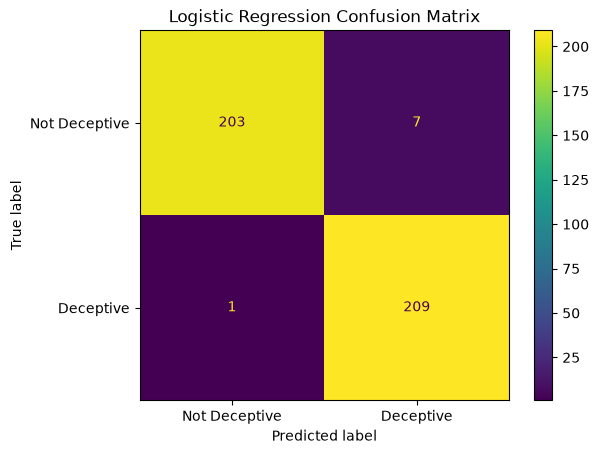

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Deceptive", "Deceptive"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [37]:
import joblib

joblib.dump(lr_model, "dark_pattern_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


In [38]:
def predict_dark_pattern(user_text):

    if not isinstance(user_text, str) or not user_text.strip():
        print("Please enter some text.")
        return

    # Convert user input using the trained TF-IDF vectorizer
    text_tfidf = tfidf.transform([user_text])

    # Get prediction
    prediction = lr_model.predict(text_tfidf)[0]

    # Get probabilities
    probabilities = lr_model.predict_proba(text_tfidf)[0]

    # Match probabilities with their class labels
    class_probabilities = dict(
        zip(lr_model.classes_, probabilities)
    )

    not_deceptive_prob = class_probabilities.get(0, 0) * 100
    deceptive_prob = class_probabilities.get(1, 0) * 100

    print("\n========================================")
    print("       DARK PATTERN ANALYSIS")
    print("========================================")

    print("\nInput:")
    print(user_text)

    print("\nProbability:")
    print("Not Deceptive :", round(not_deceptive_prob, 2), "%")
    print("Deceptive     :", round(deceptive_prob, 2), "%")

    print("\nFinal Prediction:")

    if prediction == 1:
        print("⚠️ DECEPTIVE PATTERN")
    else:
        print("✅ NOT DECEPTIVE")

    print("========================================")

In [ ]:
user_text = input("Enter a pattern: ")
predict_dark_pattern(user_text)